<a href="https://colab.research.google.com/github/dilekmirac/dip/blob/main/hafta3_g%C3%B6rev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'esitlenmis_resim.jpg' başarıyla kaydedildi.


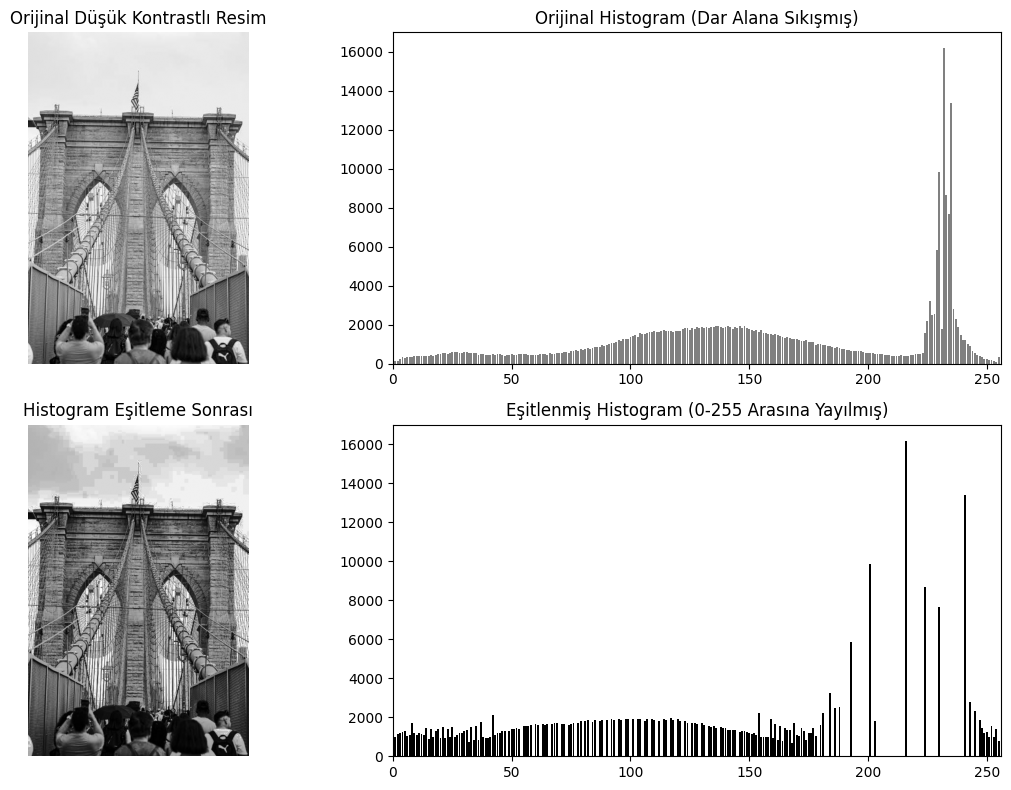

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

resim_yolu = 'dusuk_kontrast.jpg'
img = cv2.imread(resim_yolu, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Görüntü bulunamadı, test için örnek düşük kontrastlı resim üretiliyor...")

    img = np.random.randint(100, 150, (400, 400), dtype=np.uint8)

yukseklik, genislik = img.shape
toplam_piksel = yukseklik * genislik

histogram = [0] * 256

for i in range(yukseklik):
    for j in range(genislik):
        piksel_degeri = img[i, j]
        histogram[piksel_degeri] += 1

cdf = [0] * 256
toplam = 0

for i in range(256):
    toplam += histogram[i]
    cdf[i] = toplam

cdf_min = 0
for deger in cdf:
    if deger > 0:
        cdf_min = deger
        break

esitlenmis_degerler = [0] * 256

for i in range(256):
    pay = cdf[i] - cdf_min
    payda = toplam_piksel - cdf_min

    if payda > 0:
        yeni_deger = round((pay / payda) * 255)
        esitlenmis_degerler[i] = max(0, min(255, yeni_deger))

esitlenmis_img = np.zeros((yukseklik, genislik), dtype=np.uint8)

for i in range(yukseklik):
    for j in range(genislik):
        eski_deger = img[i, j]
        esitlenmis_img[i, j] = esitlenmis_degerler[eski_deger]

cv2.imwrite('esitlenmis_resim.jpg', esitlenmis_img)
print("'esitlenmis_resim.jpg' başarıyla kaydedildi.")

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Orijinal Düşük Kontrastlı Resim")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.bar(range(256), histogram, color='gray')
plt.title("Orijinal Histogram (Dar Alana Sıkışmış)")
plt.xlim([0, 256])

plt.subplot(2, 2, 3)
plt.imshow(esitlenmis_img, cmap='gray', vmin=0, vmax=255)
plt.title("Histogram Eşitleme Sonrası")
plt.axis('off')

yeni_histogram = [0] * 256
for i in range(yukseklik):
    for j in range(genislik):
        yeni_histogram[esitlenmis_img[i, j]] += 1

plt.subplot(2, 2, 4)
plt.bar(range(256), yeni_histogram, color='black')
plt.title("Eşitlenmiş Histogram (0-255 Arasına Yayılmış)")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

'esitlenmis_resim_hazir.jpg' hazır fonksiyon ile kaydedildi.


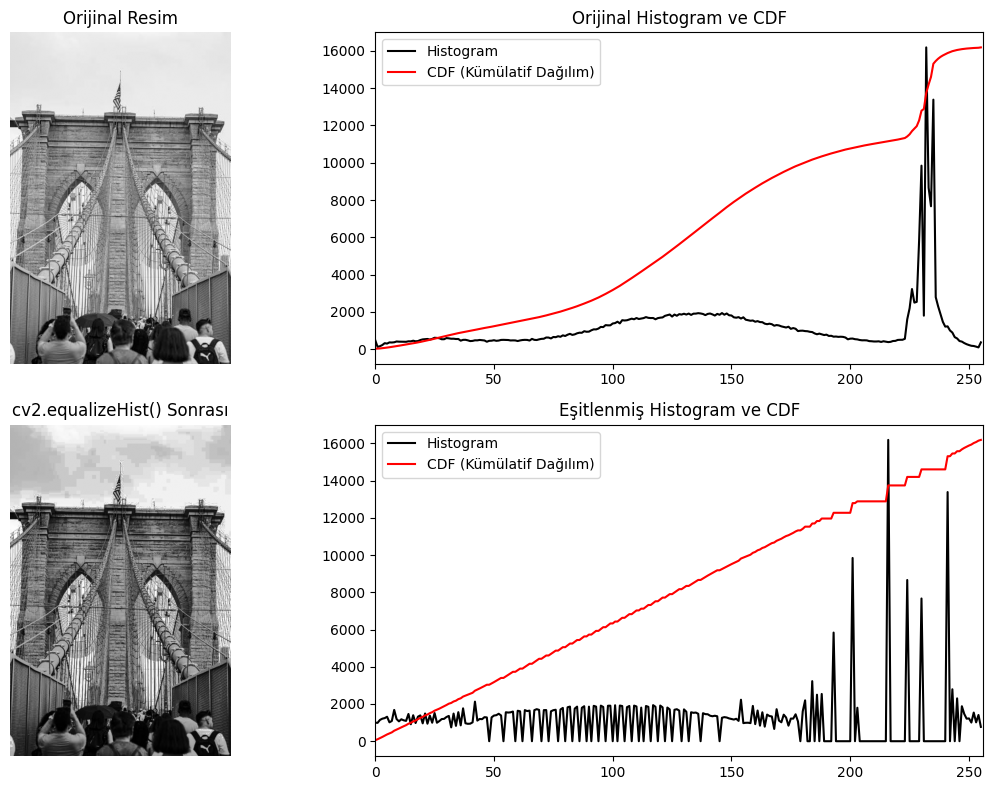

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('dusuk_kontrast.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(100, 150, (400, 400), dtype=np.uint8)


esitlenmis_img = cv2.equalizeHist(img)

cv2.imwrite('esitlenmis_resim_hazir.jpg', esitlenmis_img)
print("'esitlenmis_resim_hazir.jpg' hazır fonksiyon ile kaydedildi.")


hist_orijinal = cv2.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

cdf_orijinal = np.cumsum(hist_orijinal)
cdf_normalize = cdf_orijinal * float(hist_orijinal.max()) / cdf_orijinal.max()

hist_esitlenmis = cv2.calcHist([esitlenmis_img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])
cdf_esitlenmis = np.cumsum(hist_esitlenmis)
cdf_esitlenmis_normalize = cdf_esitlenmis * float(hist_esitlenmis.max()) / cdf_esitlenmis.max()

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Orijinal Resim")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(hist_orijinal, color='black', label='Histogram')
plt.plot(cdf_normalize, color='red', label='CDF (Kümülatif Dağılım)')
plt.legend(loc='upper left')
plt.title("Orijinal Histogram ve CDF")
plt.xlim([0, 256])

plt.subplot(2, 2, 3)
plt.imshow(esitlenmis_img, cmap='gray', vmin=0, vmax=255)
plt.title("cv2.equalizeHist() Sonrası")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.plot(hist_esitlenmis, color='black', label='Histogram')
plt.plot(cdf_esitlenmis_normalize, color='red', label='CDF (Kümülatif Dağılım)')
plt.legend(loc='upper left')
plt.title("Eşitlenmiş Histogram ve CDF")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()